In [1]:
import numpy as np
import trackpy as tp
import matplotlib.pyplot as plt
import zarr
import tqdm

za = zarr.open_array("/Volumes/data/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/MTs_red.zarr", read_only=True)
MTs = za[:]
output = "/Volumes/data/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop"#"/Volumes/data/Sasaki/backup_git/MTCargo_analysis/experiment/20251225/MC03MT"
output2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20260121/beads_trans_crop_crop"

In [2]:
diff = MTs[1:] - MTs[:-1]

In [11]:
import cv2

medians = []

for d in diff:
    median = cv2.medianBlur(d, 5)
    medians.append(median)
medians = np.array(medians)

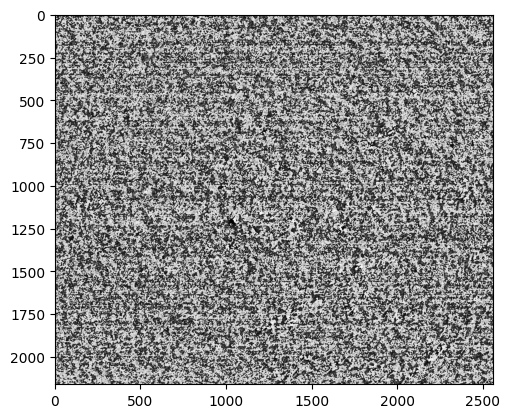

In [13]:
plt.imshow(medians[0], cmap='gray')

(array([ 567282., 1487666.,  462999.,  102320.,   16775.,   17850.,
         116059.,  471906., 1681484.,  605259.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

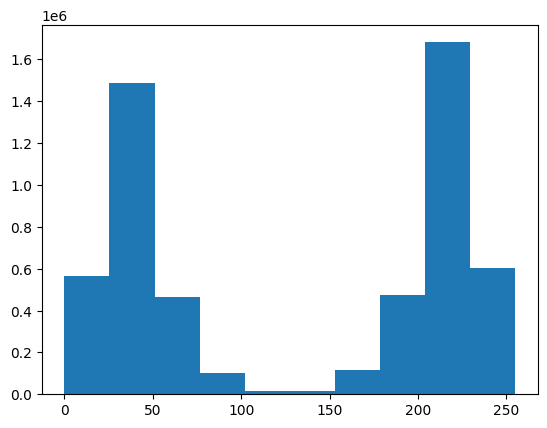

In [14]:
plt.hist(medians[0].reshape(-1))

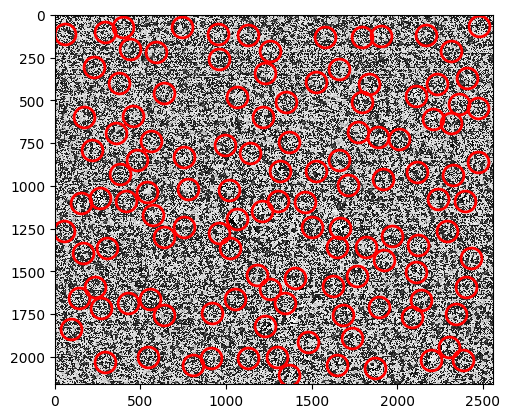

/Users/sasakinozomu/code/MTCargo_analysis/venv/lib/python3.13/site-packages/trackpy/plots.py:643: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  axlist = f[pos_columns].applymap(lambda x: x % 1).hist()


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>]],
      dtype=object)

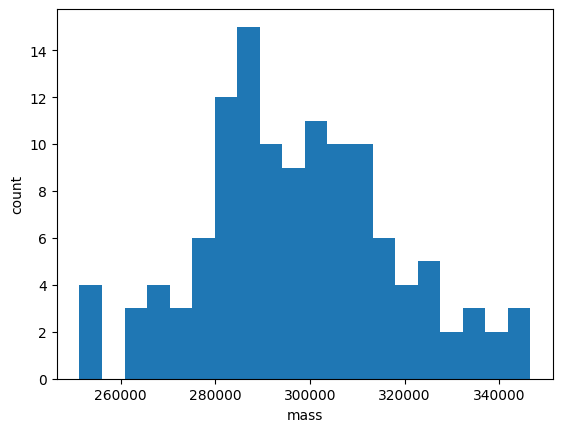

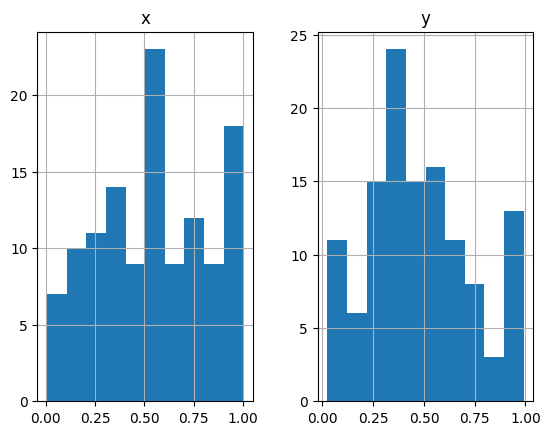

In [15]:
diameter = 1.18*10
scale = 0.11
time_inerval = 4 #timescle

pxdiameter =int(diameter/scale)
if pxdiameter % 2 ==0:
    pxdiameter = pxdiameter + 1

minmass = 0
threshold = 0

f = tp.locate(medians[0], pxdiameter, minmass = minmass, threshold=threshold)
tp.annotate(f, medians[0])

fig, ax = plt.subplots()
ax.hist(f['mass'], bins=20)
# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count');

tp.subpx_bias(f)

In [29]:
f = tp.batch(diff, pxdiameter, minmass = minmass, threshold=threshold)

Frame 269: 130 features


In [32]:
cargo_velocity = 0.7 #大体の輸送速度（trackingのdistanceを計測するために使うので大体でいい）
distance = int(cargo_velocity * time_inerval / scale)

tracks = tp.link(f, distance)

tracks = tp.link(f, distance, memory=10)
t1 = tp.filter_stubs(tracks, 10)

Frame 269: 130 trajectories present.


/Users/sasakinozomu/code/MTCargo_analysis/libs/remove_fixed.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  distances = grouped.apply(lambda df: np.sqrt(


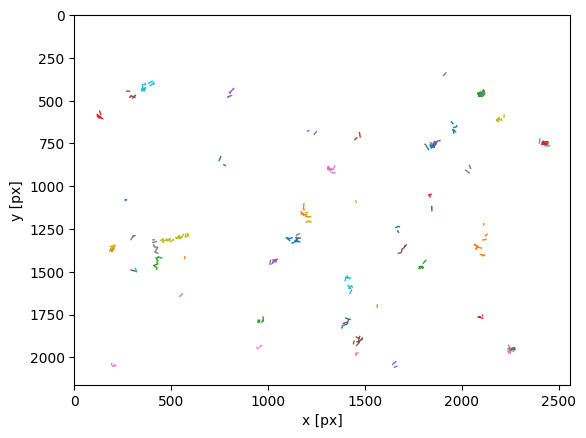

/Users/sasakinozomu/code/MTCargo_analysis/libs/remove_fixed.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  distances = grouped.apply(lambda df: np.sqrt(


't2.to_csv(f"{output}/beads_tracks.csv", index=False)\nt2.to_csv(f"{output2}/beads_tracks.csv", index=False)'

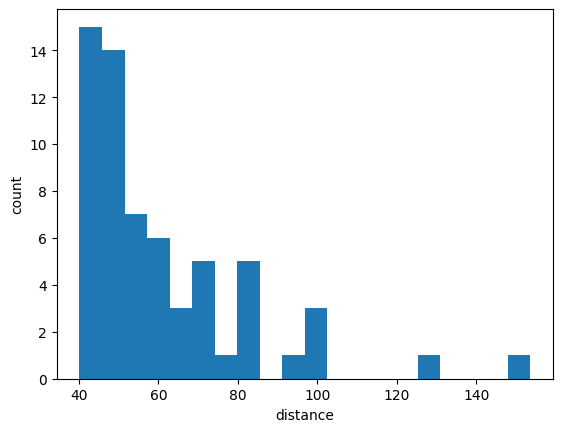

In [33]:
threshold = 40
import os
import sys
sys.path.append(os.path.abspath(".."))
from libs import remove_fixed as rf 

t2 = rf.remove_fixed(t1, threshold)

plt.figure()
plt.xlim((0, 2560))
plt.ylim((0, 2160))
tp.plot_traj(t2);

tracks_dist2 = rf.cal_dis(t2)

fig, ax = plt.subplots()
ax.hist(tracks_dist2["distance"], bins=20)

# Optionally, label the axes.
ax.set(xlabel='distance', ylabel='count');
os.makedirs(output, exist_ok=True)
os.makedirs(output2, exist_ok=True)
"""t2.to_csv(f"{output}/beads_tracks.csv", index=False)
t2.to_csv(f"{output2}/beads_tracks.csv", index=False)"""

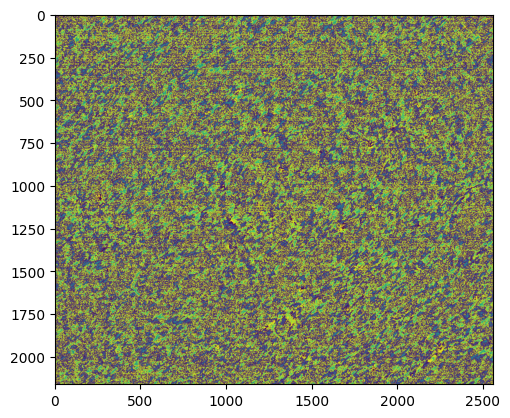

In [38]:
plt.imshow(MTs[2]-MTs[0])